# Week 10 - Transformers for Custom Text Classification

**DMML - Data Mining & Machine Learning**  
**Due:** End of Week 11  
**Estimated time:** 4-5 hours

This notebook fine-tunes a pretrained transformer for a specific text task: emotion classification. The goal is to experience the modern NLP workflow: start from a pretrained model, adapt it to your labels, compare it to a simpler baseline, then try it on custom text.


## What You Are Building

This week has five required implementation pieces:

1. `load_emotion_subset(train_size, test_size, random_state)` - load and sample a manageable emotion-classification dataset.
2. `train_tfidf_baseline(train_df, test_df)` - train a simple text baseline.
3. `tokenize_dataset(dataset_dict, tokenizer, max_length)` - prepare text for a transformer.
4. `predict_emotion(texts, model, tokenizer, id2label, device)` - run the fine-tuned transformer on custom text.
5. `make_benchmark_long(results, week, dataset, task_type, target, split)` - append text-classification results to the reusable benchmark format.

The modelling question is practical: when you fine-tune a pretrained language model for a specific label set, how much do you gain over a simpler bag-of-words baseline, and what kinds of custom examples does it handle well or badly?


In [1]:
# Imports - keep this cell stable
import warnings
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline

try:
    from datasets import Dataset, DatasetDict, load_dataset
    from transformers import (
        AutoModelForSequenceClassification,
        AutoTokenizer,
        DataCollatorWithPadding,
        Trainer,
        TrainingArguments,
    )
except ImportError as exc:
    raise ImportError("This notebook requires datasets and transformers. Install them with: pip install datasets transformers") from exc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TRAIN_SIZE = 4000
TEST_SIZE = 1000
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
print("Using device:", DEVICE)


Using device: cpu


## Dataset and Download Note

This notebook uses the HuggingFace `dair-ai/emotion` dataset. It contains short English texts labelled with six emotions: sadness, joy, love, anger, fear, and surprise.

The first run downloads both the dataset and the pretrained DistilBERT model. This is intentional: downloading and adapting pretrained models is part of the modern AI workflow.


## Task 1 - Load an Emotion Dataset Subset

Implement `load_emotion_subset(train_size, test_size, random_state)`.

Return:

```python
train_df, test_df, label_names, id2label, label2id
```

Requirements:

- Load the HuggingFace `emotion` dataset.
- Sample `train_size` examples from the train split and `test_size` examples from the test split.
- Return pandas dataframes with columns `text` and `label`.
- Build `id2label` and `label2id` dictionaries.


In [2]:
def load_emotion_subset(train_size: int = TRAIN_SIZE, test_size: int = TEST_SIZE, random_state: int = RANDOM_STATE):
    """Load sampled train/test dataframes from the HuggingFace emotion dataset."""
    dataset = load_dataset("dair-ai/emotion")
    label_names = dataset["train"].features["label"].names
    id2label = {i: label for i, label in enumerate(label_names)}
    label2id = {label: i for i, label in id2label.items()}

    train_df = dataset["train"].shuffle(seed=random_state).select(range(train_size)).to_pandas()
    test_df = dataset["test"].shuffle(seed=random_state).select(range(test_size)).to_pandas()

    train_df = train_df[["text", "label"]].reset_index(drop=True)
    test_df = test_df[["text", "label"]].reset_index(drop=True)
    return train_df, test_df, label_names, id2label, label2id


In [3]:
# Self-check: Task 1
train_df, test_df, label_names, id2label, label2id = load_emotion_subset()

assert isinstance(train_df, pd.DataFrame)
assert isinstance(test_df, pd.DataFrame)
assert {"text", "label"}.issubset(train_df.columns)
assert {"text", "label"}.issubset(test_df.columns)
assert len(train_df) == TRAIN_SIZE
assert len(test_df) == TEST_SIZE
assert len(label_names) == 6
assert set(id2label.keys()) == set(range(len(label_names)))
assert set(label2id.values()) == set(range(len(label_names)))

print("Task 1 passed")
display(train_df.head())
print(label_names)


Task 1 passed


,text,label
0,while cycling in the country,4
1,i had pocket qq and was feeling pretty confide...,1
2,i am in no way complaining or whining or feeli...,0
3,i feel a bit stressed because it feels like im...,3
4,i tell the people closest to me things that i ...,5


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


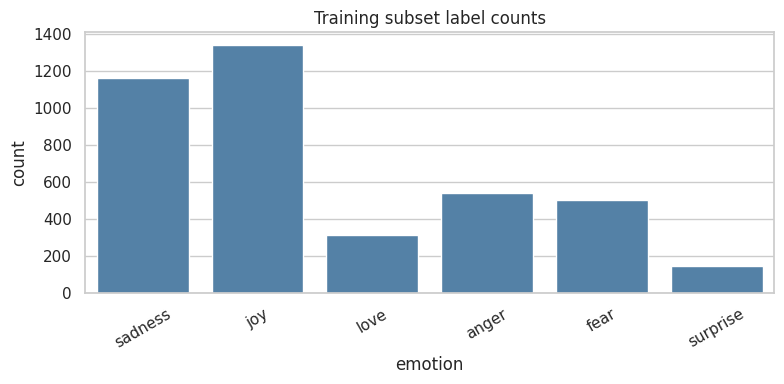

,text,label,emotion
555,i feel ignored even if that ignoring is someth...,0,sadness
3491,ive decided that whenever i start to feel mad ...,3,anger
527,i feel safe secure and protected when im in my...,1,joy
3925,i can t help but feel a little hesitant toward...,4,fear
2989,i am feeling rather vain today because my hair...,0,sadness


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = train_df["label"].map(id2label).value_counts().reindex(label_names)
sns.barplot(x=counts.index, y=counts.values, ax=ax, color="steelblue")
ax.set_title("Training subset label counts")
ax.set_xlabel("emotion")
ax.set_ylabel("count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

train_df.assign(emotion=train_df["label"].map(id2label)).sample(5, random_state=RANDOM_STATE)


## Task 2 - Train a TF-IDF Baseline

Implement `train_tfidf_baseline(train_df, test_df)`.

Train a pipeline with:

- `TfidfVectorizer(max_features=20000, ngram_range=(1, 2))`
- `LogisticRegression(max_iter=1000)`

Return `(model, result)` where `result` is a dictionary with:

- `model`
- `accuracy`
- `f1_macro`
- `fit_time_sec`

This baseline is intentionally strong. The transformer should earn its place.


In [5]:
def train_tfidf_baseline(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """Train a TF-IDF logistic regression baseline and return (model, result_dict)."""
    model = Pipeline(
        [
            ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000)),
            ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]
    )

    start = perf_counter()
    model.fit(train_df["text"], train_df["label"])
    fit_time = perf_counter() - start
    predictions = model.predict(test_df["text"])

    result = {
        "model": "tfidf_logistic_regression",
        "accuracy": float(accuracy_score(test_df["label"], predictions)),
        "f1_macro": float(f1_score(test_df["label"], predictions, average="macro")),
        "fit_time_sec": float(fit_time),
    }
    return model, result


In [6]:
# Self-check: Task 2
tfidf_model, tfidf_result = train_tfidf_baseline(train_df, test_df)

expected_keys = {"model", "accuracy", "f1_macro", "fit_time_sec"}
assert set(tfidf_result.keys()) == expected_keys
assert tfidf_result["model"] == "tfidf_logistic_regression"
assert 0 <= tfidf_result["accuracy"] <= 1
assert 0 <= tfidf_result["f1_macro"] <= 1
assert tfidf_result["fit_time_sec"] >= 0

print("Task 2 passed")
tfidf_result


Task 2 passed


{'model': 'tfidf_logistic_regression',
 'accuracy': 0.671,
 'f1_macro': 0.44325712358900443,
 'fit_time_sec': 7.457330215002003}

## Task 3 - Tokenize for DistilBERT

Implement `tokenize_dataset(dataset_dict, tokenizer, max_length)`.

Input:

- a HuggingFace `DatasetDict` with train and test splits;
- a tokenizer;
- a maximum sequence length.

Return a tokenized `DatasetDict` suitable for `Trainer`. Use truncation. You do not need to pad here; the data collator will pad dynamically by batch.


In [7]:
def tokenize_dataset(dataset_dict: DatasetDict, tokenizer, max_length: int = MAX_LENGTH):
    """Tokenize a DatasetDict for transformer fine-tuning."""
    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, max_length=max_length)

    return dataset_dict.map(tokenize_batch, batched=True)


In [8]:
# Build HuggingFace datasets from the sampled dataframes.
# This avoids relying on original dataset indices after sampling.
raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False),
    "test": Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False),
})

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenized = tokenize_dataset(raw_datasets, tokenizer, max_length=MAX_LENGTH)

assert "input_ids" in tokenized["train"].column_names
assert "attention_mask" in tokenized["train"].column_names
assert "label" in tokenized["train"].column_names
assert len(tokenized["train"]) == TRAIN_SIZE
assert len(tokenized["test"]) == TEST_SIZE
assert len(tokenized["train"][0]["input_ids"]) <= MAX_LENGTH

print("Task 3 passed")


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Task 3 passed


## Fine-Tune DistilBERT

This cell performs the adaptation step. You replace the classification head with six emotion labels, then fine-tune the model on the sampled dataset.


In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

transformer_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
).to(DEVICE)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./w10_emotion_distilbert",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
    seed=RANDOM_STATE,
)

trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

start = perf_counter()
trainer.train()
transformer_fit_time = perf_counter() - start
transformer_metrics = trainer.evaluate()
transformer_metrics


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.735518,0.596162,0.810000,0.569260
2,0.442660,0.415550,0.873000,0.734049


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.442660,0.415550,2,0.873000,0.734049


{'eval_loss': 0.41554969549179077,
 'eval_accuracy': 0.873,
 'eval_f1_macro': 0.7340485160483786}

## Task 4 - Predict Emotion for Custom Text

Implement `predict_emotion(texts, model, tokenizer, id2label, device)`.

Requirements:

- Accept either one string or a list of strings.
- Return a dataframe with columns `text`, `predicted_label`, and `confidence`.
- Use the transformer model's softmax probabilities.

After implementing it, you will test the fine-tuned model on your own sentences.


In [10]:
def predict_emotion(texts, model, tokenizer, id2label: dict, device=DEVICE) -> pd.DataFrame:
    """Predict emotion labels for custom text using a fine-tuned transformer."""
    if isinstance(texts, str):
        texts = [texts]

    model.eval()
    model.to(device)
    encoded = tokenizer(texts, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
    encoded = {key: value.to(device) for key, value in encoded.items()}

    with torch.no_grad():
        logits = model(**encoded).logits
        probabilities = torch.softmax(logits, dim=1)
        confidence, predicted_ids = probabilities.max(dim=1)

    predicted_ids = predicted_ids.cpu().numpy()
    confidence = confidence.cpu().numpy()
    labels = [id2label[int(label_id)] for label_id in predicted_ids]

    return pd.DataFrame(
        {
            "text": list(texts),
            "predicted_label": labels,
            "confidence": confidence.astype(float),
        },
        columns=["text", "predicted_label", "confidence"],
    )


In [11]:
# Self-check: Task 4
custom_texts = [
    "I cannot believe this finally worked, I am so relieved.",
    "This is exactly the kind of bug that ruins an afternoon.",
    "The result is fine, I guess, which is apparently a miracle now.",
    "I miss the old version more than I expected.",
    "Wait, that actually solved the whole problem?",
]

custom_predictions = predict_emotion(custom_texts, transformer_model, tokenizer, id2label, device=DEVICE)

assert isinstance(custom_predictions, pd.DataFrame)
assert list(custom_predictions.columns) == ["text", "predicted_label", "confidence"]
assert len(custom_predictions) == len(custom_texts)
assert custom_predictions["predicted_label"].isin(label_names).all()
assert custom_predictions["confidence"].between(0, 1).all()

print("Task 4 passed")
custom_predictions


Task 4 passed


,text,predicted_label,confidence
0,"I cannot believe this finally worked, I am so ...",joy,0.915006
1,This is exactly the kind of bug that ruins an ...,sadness,0.693130
2,"The result is fine, I guess, which is apparent...",joy,0.916401
3,I miss the old version more than I expected.,sadness,0.905994
4,"Wait, that actually solved the whole problem?",joy,0.331259


## Compare Transformer Mistakes

Inspect a confusion matrix for the fine-tuned model. Multi-class emotion classification is harder than binary sentiment; related emotions may be confused.


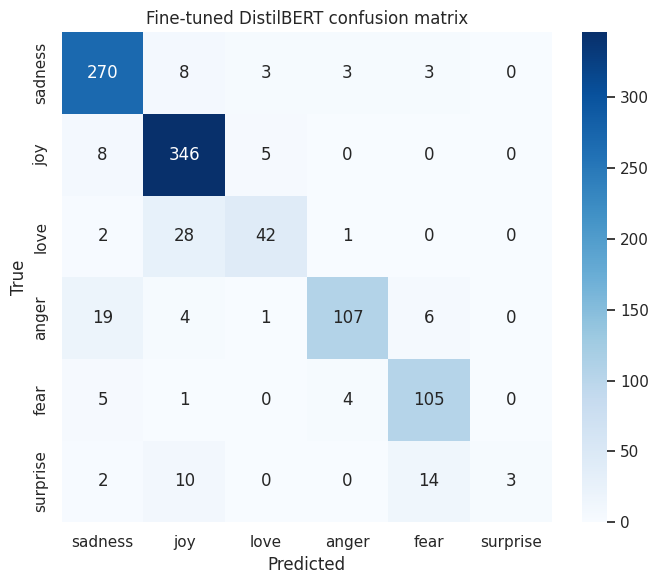

In [12]:
pred_output = trainer.predict(tokenized["test"])
y_true = np.array(pred_output.label_ids)
y_pred = np.argmax(pred_output.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Fine-tuned DistilBERT confusion matrix")
plt.tight_layout()
plt.show()


## Task 5 - Benchmark Long Format

Implement `make_benchmark_long(results, week, dataset, task_type, target, split)`.

Convert model results into long benchmark format:

- `week`
- `dataset`
- `task_type`
- `target`
- `model`
- `metric`
- `score`
- `split`
- `notes`

Include numeric metric columns such as `accuracy` and `f1_macro`. Do not include `fit_time_sec` as a metric.


In [13]:
def make_benchmark_long(
    results: pd.DataFrame,
    week: str,
    dataset: str,
    task_type: str,
    target: str,
    split: str,
) -> pd.DataFrame:
    """Convert text-classification results to the cumulative benchmark long format."""
    metric_columns = [column for column in results.columns if column not in ["model", "fit_time_sec"]]
    rows = []

    for _, result in results.iterrows():
        for metric in metric_columns:
            if pd.isna(result[metric]):
                continue
            rows.append(
                {
                    "week": week,
                    "dataset": dataset,
                    "task_type": task_type,
                    "target": target,
                    "model": result["model"],
                    "metric": metric,
                    "score": float(result[metric]),
                    "split": split,
                    "notes": "emotion text subset; TF-IDF baseline and fine-tuned DistilBERT",
                }
            )

    columns = ["week", "dataset", "task_type", "target", "model", "metric", "score", "split", "notes"]
    return pd.DataFrame(rows, columns=columns)


In [14]:
transformer_result = {
    "model": "distilbert_finetuned_emotion",
    "accuracy": transformer_metrics["eval_accuracy"],
    "f1_macro": transformer_metrics["eval_f1_macro"],
    "fit_time_sec": transformer_fit_time,
}

all_results = pd.DataFrame([tfidf_result, transformer_result]).sort_values("f1_macro", ascending=False).reset_index(drop=True)

benchmark_long = make_benchmark_long(
    all_results,
    week="W10",
    dataset="Emotion subset",
    task_type="text_classification",
    target="emotion",
    split=f"train_{TRAIN_SIZE}_test_{TEST_SIZE}_random_state_42",
)

expected_cols = ["week", "dataset", "task_type", "target", "model", "metric", "score", "split", "notes"]
assert list(benchmark_long.columns) == expected_cols
assert {"accuracy", "f1_macro"}.issubset(set(benchmark_long["metric"]))
assert "fit_time_sec" not in set(benchmark_long["metric"])
assert benchmark_long["score"].between(0, 1).all()

print("Task 5 passed")
benchmark_long.head(10)


Task 5 passed


,week,dataset,task_type,target,model,metric,score,split,notes
0,W10,Emotion subset,text_classification,emotion,distilbert_finetuned_emotion,accuracy,0.873000,train_4000_test_1000_random_state_42,emotion text subset; TF-IDF baseline and fine-...
1,W10,Emotion subset,text_classification,emotion,distilbert_finetuned_emotion,f1_macro,0.734049,train_4000_test_1000_random_state_42,emotion text subset; TF-IDF baseline and fine-...
2,W10,Emotion subset,text_classification,emotion,tfidf_logistic_regression,accuracy,0.671000,train_4000_test_1000_random_state_42,emotion text subset; TF-IDF baseline and fine-...
3,W10,Emotion subset,text_classification,emotion,tfidf_logistic_regression,f1_macro,0.443257,train_4000_test_1000_random_state_42,emotion text subset; TF-IDF baseline and fine-...


## Benchmark Wide View

This is the key comparison: a strong bag-of-words baseline vs a fine-tuned transformer on a specific text classification task.


In [15]:
benchmark_wide = (
    benchmark_long
    .pivot_table(
        index=["dataset", "task_type", "target", "metric", "split"],
        columns="model",
        values="score",
        aggfunc="first",
    )
    .reset_index()
)
benchmark_wide.columns.name = None
benchmark_wide


,dataset,task_type,target,metric,split,distilbert_finetuned_emotion,tfidf_logistic_regression
0,Emotion subset,text_classification,emotion,accuracy,train_4000_test_1000_random_state_42,0.873000,0.671000
1,Emotion subset,text_classification,emotion,f1_macro,train_4000_test_1000_random_state_42,0.734049,0.443257


## Reflection

Answer briefly, but concretely.

1. Did fine-tuned DistilBERT beat the TF-IDF baseline? Was the gain worth the extra machinery?
2. Which emotions were most often confused? Why might those labels be hard to separate?
3. Write two additional custom sentences that are personally relevant to this course or your project. What did the model predict?
4. Where would this workflow be useful outside movie reviews or toy examples?


## Challenge Tracks Optional

Choose zero, one, or more.

### Track A - Course Feedback Classifier
Write 20 short synthetic course-feedback messages and label them with emotions. Run your model on them and inspect where it disagrees with you.

### Track B - Freeze vs Fine-Tune
Freeze the DistilBERT base and train only the classification head. Compare to full fine-tuning.

### Track C - Attention Inspection
Run one custom sentence with `output_attentions=True` and visualise which tokens receive attention in the last layer.


In [16]:
# Optional challenge workspace
# Your code here
